# 1. 서울시 119 이송 건수·인구 밀집 — 전처리

**흐름**
- 최종 csv 불러오기 → 사용할 파일 고르기 → 이송 건수 정답 정리 → 시계열 분해 → 학습 데이터 생성 → 특성 선택 → 미래 예측용 입력 행 생성

**결과 파일 (`ml_data` 폴더)**

| 파일 | 내용 |
|---|---|
| `transport_dataset.csv` | 이송 건수 학습 데이터 전체 (자치구 × 월) |
| `transport_selected.csv` | 선택된 특성만 남긴 이송 건수 데이터 |
| `transport_future.csv` | 미래 예측용 입력 행 (정답 없음) |
| `features_transport.csv` | 이송 건수 특성 선택 결과와 이유 |
| `population_dataset.csv` | 인구 밀집 학습 데이터 전체 (자치구 × 일) |
| `population_selected.csv` | 선택된 특성만 남긴 인구 밀집 데이터 |
| `features_population.csv` | 인구 밀집 특성 선택 결과와 이유 |
| `excluded_columns.csv` | 중복·값 하나뿐이라 뺀 컬럼 |
| `ref_er_beds_realtime.csv` | (참고용) 구별 실시간 응급실 가용병상 |
| `ref_er_institutions.csv` | (참고용) 구별 응급실 운영기관 수·허가병상 수 |
| `ref_beds_2014_2016.csv` | (참고용) 구별 병상 수 (통계청) |

- `ref_` 파일 : 모델 학습에 쓰지 않는 참고 표

## 0. 환경 설정
- 경로 : `BASE_DIR` 하나만 바꾸면 나머지 폴더가 따라 바뀜
- 폴더 역할 : `outputs`(최종 데이터 csv) · `ml_data`(학습 데이터) · `ml_result`(그래프)
- `SELECT_END` : 특성 선택은 이 날짜 이전 데이터만 사용 (테스트 기간 정보 누출 방지)
- `FORECAST_MONTHS` : 미래 예측용 입력 행을 만들 개월 수

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from statsmodels.tsa.seasonal import seasonal_decompose
try:
    from IPython.display import display   # 주피터 표 출력
except ImportError:
    display = print                        # .py 단독 실행 시 print로 대체

# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
DATA_DIR = BASE_DIR / 'data'
OUT_DIR = BASE_DIR / 'outputs'
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
for d in [OUT_DIR, ML_DATA_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FORECAST_MONTHS = 6    # 미래 6개월
SELECT_END = '2025-01-01'   # 특성 선택에 쓸 마지막 날짜(미포함) = 예측 노트북의 테스트 시작일과 같게

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
VALID_GU = set(GU_LIST)

print('OUT_DIR    :', OUT_DIR)
print('ML_DATA_DIR:', ML_DATA_DIR)
print('RESULT_DIR :', RESULT_DIR)

OUT_DIR    : C:\ai\source\09_Project\cheolhyeon_jo\outputs
ML_DATA_DIR: C:\ai\source\09_Project\cheolhyeon_jo\ml_data
RESULT_DIR : C:\ai\source\09_Project\cheolhyeon_jo\ml_result


In [2]:
# 자주 쓰는 함수

def month_start(s):
    # 날짜를 그 달의 1일로 통일
    return pd.to_datetime(s, errors='coerce').dt.to_period('M').dt.to_timestamp()


def find_file(folder, name):
    # name.csv 또는 '숫자_name.csv' 중 가장 최근 파일, 없으면 None
    found = list(Path(folder).glob(name + '.csv')) + list(Path(folder).glob('*_' + name + '.csv'))
    if not found:
        return None
    return max(found, key=lambda p: p.stat().st_mtime)

## 1. 최종 데이터 불러오기
- 위치 : `outputs` (전처리 1 노트북의 결과 폴더)
- 파일 이름 앞에 숫자가 붙어 있어도 찾음 (`find_file`)
- 컬럼 이름 통일 : `district` → `District`, `ds` → 날짜형

In [3]:
FILE_NAMES = [
    'accident_cause_long', 'accident_cause_onehot',
    'ambulance_citywide_monthly', 'ambulance_incident_monthly', 'ambulance_monthly_gu_2022_2024',
    'ambulance_prophet', 'ambulance_prophet_201701_202512_api', 'ambulance_prophet_202512_api', 'ambulance_nodata',
    'ambulance_sample_gwanak_202506',
    'medical_flow_district_demand', 'medical_flow_district_supply', 'medical_flow_seoul_od_matrix',
    'population_rf', 'realtime_er_beds',
]

raw = {}
for name in FILE_NAMES:
    path = find_file(OUT_DIR, name)
    if path is None:
        print(f'[없음] {name}.csv')
        continue
    df = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    df = df.rename(columns={'district': 'District', '환자_district': '환자_District', '병원_district': '병원_District'})
    if 'ds' in df.columns:
        df['ds'] = pd.to_datetime(df['ds'], errors='coerce')
    if 'ym' in df.columns:
        df['ym'] = pd.to_datetime(df['ym'], errors='coerce')
    raw[name] = df
    print(f'{name:40s} {str(df.shape):12s} <- {path.name}')

accident_cause_long                      (4950, 4)    <- accident_cause_long.csv
accident_cause_onehot                    (500, 16)    <- accident_cause_onehot.csv
ambulance_citywide_monthly               (48, 5)      <- ambulance_citywide_monthly.csv
ambulance_incident_monthly               (600, 9)     <- ambulance_incident_monthly.csv
ambulance_monthly_gu_2022_2024           (900, 3)     <- ambulance_monthly_gu_2022_2024.csv
ambulance_prophet                        (525, 6)     <- ambulance_prophet.csv
ambulance_prophet_201701_202512_api      (2634, 5)    <- ambulance_prophet_201701_202512_api.csv
ambulance_prophet_202512_api             (25, 5)      <- ambulance_prophet_202512_api.csv
ambulance_nodata                         (66, 2)      <- ambulance_nodata.csv
ambulance_sample_gwanak_202506           (1, 4)       <- ambulance_sample_gwanak_202506.csv
medical_flow_district_demand             (150, 7)     <- medical_flow_district_demand.csv
medical_flow_district_supply             (

## 2. 사용할 파일 고르기

| 파일 | 결정 | 이유 |
|---|---|---|
| `ambulance_prophet_201701_202512_api` | **정답(이송 건수)** | 2017~2025년 거의 모든 달, 한 가지 집계 기준 |
| `ambulance_prophet_202512_api` | 제외 | 위 API 파일 안에 같은 행이 모두 있음 |
| `ambulance_incident_monthly` | 제외 | 사고 **발생 구** 기준 (API는 **소방서 관할** 기준) → 섞으면 같은 구의 수준이 들쭉날쭉 |
| `ambulance_monthly_gu_2022_2024` | 제외 | 출동 건수만 있음, API와 기간 겹침 |
| `ambulance_prophet` | 제외 | 연 단위 |
| `ambulance_citywide_monthly` | 제외 | 서울 전체 합계 (구 단위 아님) |
| `ambulance_sample_gwanak_202506` | 제외 | 1개 구 1개월 표본 |
| `accident_cause_long` | 제외 | `accident_cause_onehot`과 같은 내용 (형태만 다름) |
| `medical_flow_seoul_od_matrix` | 제외 | 구별 합계가 수요·공급 표와 같음 |
| `realtime_er_beds` | 제외 | 실시간 병상 스냅샷 (월별 예측과 시간 단위 다름) |

아래 셀에서 표의 판단 근거를 직접 확인합니다.

In [4]:
def is_contained(small, big, keys):
    # small의 모든 행이 big 안에 똑같이 있는지
    check = small.merge(big.drop_duplicates(keys), how='left', on=list(small.columns), indicator=True)
    return (check['_merge'] == 'both').all()


api = raw['ambulance_prophet_201701_202512_api'].copy()
print('202512 파일이 전체 API 안에 포함:', is_contained(raw['ambulance_prophet_202512_api'], api, ['ds', 'District']))

# long <-> onehot
long_df = raw['accident_cause_long']
wide = long_df.pivot_table(index=['ds', 'District'], columns='cause', values='rescued_count', aggfunc='sum', fill_value=0)
onehot = raw['accident_cause_onehot'].set_index(['ds', 'District'])
print('사고 원인 long = onehot:', np.allclose(wide.loc[onehot.index, onehot.columns], onehot))

# OD 합계 <-> 수요·공급
od = raw['medical_flow_seoul_od_matrix']
od_p = od.groupby(['ds', '환자_District'])['입원연인원'].sum()
od_h = od.groupby(['ds', '병원_District'])['입원연인원'].sum()
dem = raw['medical_flow_district_demand'].set_index(['ds', 'District'])['서울내입원연인원']
sup = raw['medical_flow_district_supply'].set_index(['ds', 'District'])['서울내환자연인원']
print('OD 합계 = 수요 서울내:', np.allclose(od_p.loc[dem.index], dem))
print('OD 합계 = 공급 서울내:', np.allclose(od_h.loc[sup.index], sup))

# 건별 집계(발생 구) vs API(소방서 관할) 이송 건수 비율
inc = raw['ambulance_incident_monthly'].merge(api, on=['ds', 'District'], suffixes=('_건별', '_API'))
ratio = (inc['transport_cnt_건별'] / inc['transport_cnt_API']).groupby(inc['District']).mean().sort_values()
print('\n건별 / API 이송 건수 비율 (1이면 같은 기준)')
print(ratio.round(2).to_string())

202512 파일이 전체 API 안에 포함: True
사고 원인 long = onehot: True
OD 합계 = 수요 서울내: True
OD 합계 = 공급 서울내: True

건별 / API 이송 건수 비율 (1이면 같은 기준)
District
구로구     0.77
양천구     0.91
마포구     0.94
서초구     0.97
서대문구    0.97
강북구     1.00
종로구     1.03
강동구     1.06
도봉구     1.09
중구      1.09
영등포구    1.12
관악구     1.13
광진구     1.13
강남구     1.14
성동구     1.15
동대문구    1.16
중랑구     1.17
노원구     1.17
용산구     1.20
송파구     1.21
은평구     1.21
성북구     1.25
강서구     1.30
동작구     1.31
금천구     1.54


## 3. 이송 건수 정답 데이터 (API, 자치구 × 월)

**소방서 신설로 관할이 바뀐 구간**
- 성동소방서 신설 전(~2017.7) : 성동구 출동이 광진구에 합산
- 금천소방서 신설 전(~2022.1) : 금천구 출동이 구로구에 합산
- 신설 첫 달 : 한 달 일부만 집계된 값
- 처리 : 해당 4개 구는 관할이 정리된 달부터 사용 (두 구가 섞인 값·부분 집계 값 제외)
- 효과 : 광진·구로의 가짜 "급감", 성동·금천의 가짜 "급증" 방지

### 3-0. API 데이터 완전성 검증
- 전체 분석기간의 **월 × 25개 자치구** 조합을 만들고 실제 API 데이터와 비교합니다.
- `ambulance_nodata`가 있으면 실제 누락 구-월과 별도 누락 목록이 일치하는지도 확인합니다.
- 같은 자치구·월이 중복 수집되었는지 먼저 확인한 뒤 관할 변경 구간을 제거합니다.


In [5]:
# API 원본의 구-월 중복 확인
duplicate_rows = api[
    api.duplicated(subset=['ds', 'District'], keep=False)
].sort_values(['District', 'ds'])

print('중복 구-월 행 수:', len(duplicate_rows))
if len(duplicate_rows) > 0:
    display(duplicate_rows.head(20))
else:
    print('중복된 자치구-월 없음')

# 전체 기간 × 25개 자치구 기준으로 행 자체가 빠진 월 확인
all_months = pd.date_range(api['ds'].min(), api['ds'].max(), freq='MS')
expected = pd.MultiIndex.from_product(
    [all_months, GU_LIST], names=['ds', 'District']
).to_frame(index=False)
actual = api[['ds', 'District']].drop_duplicates()
missing_months = (
    expected.merge(actual, on=['ds', 'District'], how='left', indicator=True)
            .query("_merge == 'left_only'")
            .drop(columns='_merge')
)

print('전체 예상 구-월:', len(expected))
print('실제 구-월     :', len(actual))
print('누락 구-월     :', len(missing_months))
display(missing_months.head(20))

# 별도 nodata 목록과 실제 API 누락 비교
if 'ambulance_nodata' in raw:
    nodata = raw['ambulance_nodata'].copy()
    nodata = nodata.rename(columns={'ym': 'ds'})
    nodata['ds'] = month_start(nodata['ds'])
    nodata = nodata[['ds', 'District']].drop_duplicates()

    missing_check = missing_months.merge(
        nodata, on=['ds', 'District'], how='outer', indicator=True
    )
    print('\n[nodata 대조 결과]')
    print(missing_check['_merge'].value_counts())
    print('\nAPI에는 없지만 nodata에도 기록되지 않은 구-월:')
    display(missing_check[missing_check['_merge'] == 'left_only'])
else:
    print('[주의] ambulance_nodata.csv가 없어 누락 목록 대조를 생략합니다.')


중복 구-월 행 수: 0
중복된 자치구-월 없음
전체 예상 구-월: 2700
실제 구-월     : 2634
누락 구-월     : 66


,ds,District
7,2017-01-01,금천구
15,2017-01-01,성동구
32,2017-02-01,금천구
40,2017-02-01,성동구
57,2017-03-01,금천구
65,2017-03-01,성동구
82,2017-04-01,금천구
90,2017-04-01,성동구
107,2017-05-01,금천구
115,2017-05-01,성동구



[nodata 대조 결과]
left_only     66
right_only     2
both           0
Name: _merge, dtype: int64

API에는 없지만 nodata에도 기록되지 않은 구-월:


,ds,District,_merge
0,2017-01-01,금천구,left_only
1,2017-01-01,성동구,left_only
2,2017-02-01,금천구,left_only
3,2017-02-01,성동구,left_only
4,2017-03-01,금천구,left_only
...,...,...,...
61,2021-08-01,금천구,left_only
62,2021-09-01,금천구,left_only
63,2021-10-01,금천구,left_only
64,2021-11-01,금천구,left_only


In [6]:
# 관할이 정리된 첫 달
STATION_SPLIT = {
    '성동구': '2017-08-01', '광진구': '2017-08-01',
    '금천구': '2022-02-01', '구로구': '2022-02-01',
}

# 확인 : 신설 전후 연평균 출동 건수
for gu in STATION_SPLIT:
    g = api[api['District'] == gu]
    print(gu, g.groupby(g['ds'].dt.year)['y'].mean().round(0).to_dict())

start = pd.to_datetime(api['District'].map(STATION_SPLIT).fillna('2000-01-01'))
before = len(api)
monthly = api[api['ds'] >= start].copy()
monthly = monthly[monthly['District'].isin(VALID_GU)].drop_duplicates(['ds', 'District'])
monthly = monthly.sort_values(['District', 'ds']).reset_index(drop=True)
monthly['출처'] = 'API'

print(f'\n관할 변경 구간 제외: {before - len(monthly)}행 / 남은 행: {len(monthly)}')
print('기간:', monthly['ds'].min().date(), '~', monthly['ds'].max().date())

성동구 {2017: 1214.0, 2018: 1394.0, 2019: 1322.0, 2020: 1188.0, 2021: 1266.0, 2022: 1401.0, 2023: 1315.0, 2024: 1229.0, 2025: 1223.0}
광진구 {2017: 2008.0, 2018: 1355.0, 2019: 1262.0, 2020: 1121.0, 2021: 1301.0, 2022: 1604.0, 2023: 1589.0, 2024: 1438.0, 2025: 1432.0}
금천구 {2022: 1058.0, 2023: 1161.0, 2024: 1077.0, 2025: 1082.0}
구로구 {2017: 3101.0, 2018: 3180.0, 2019: 3081.0, 2020: 2803.0, 2021: 3098.0, 2022: 2564.0, 2023: 2491.0, 2024: 2304.0, 2025: 2185.0}

관할 변경 구간 제외: 70행 / 남은 행: 2564
기간: 2017-01-01 ~ 2025-12-01


### 3-1. 관할 변경 처리 후 데이터 품질 확인
- 25개 자치구가 모두 존재하는지 확인합니다.
- 구별 시작월·종료월·관측 수·결측 수를 확인합니다.
- 출동·이송 건수의 음수와 `이송건수 > 출동건수` 같은 이상값은 자동 삭제하지 않고 점검 대상으로 표시합니다.


In [7]:
# 자치구 완전성
actual_gu = set(monthly['District'].dropna().unique())
print('자치구 수:', len(actual_gu))
print('빠진 자치구:', VALID_GU - actual_gu)
print('예상하지 않은 자치구:', actual_gu - VALID_GU)

# 자치구별 보유 현황
district_summary = (
    monthly.groupby('District')
           .agg(
               시작월=('ds', 'min'),
               종료월=('ds', 'max'),
               데이터수=('ds', 'count'),
               출동결측=('y', lambda x: x.isna().sum()),
               이송결측=('transport_cnt', lambda x: x.isna().sum())
           )
           .reset_index()
)
display(district_summary)

# 값 범위 검증
for col in ['y', 'transport_cnt']:
    print(
        f'{col}: 결측={monthly[col].isna().sum()}, '
        f'음수={(monthly[col] < 0).sum()}, '
        f'최소={monthly[col].min()}, 최대={monthly[col].max()}'
    )

invalid_transport = monthly[monthly['transport_cnt'] > monthly['y']]
print('이송건수 > 출동건수인 행:', len(invalid_transport))
if len(invalid_transport) > 0:
    display(invalid_transport.head(20))


자치구 수: 25
빠진 자치구: set()
예상하지 않은 자치구: set()


,District,시작월,종료월,데이터수,출동결측,이송결측
0,강남구,2017-01-01,2025-12-01,108,0,0
1,강동구,2017-01-01,2025-12-01,108,0,0
2,강북구,2017-01-01,2025-12-01,108,0,0
3,강서구,2017-01-01,2025-12-01,108,0,0
4,관악구,2017-01-01,2025-12-01,108,0,0
5,광진구,2017-08-01,2025-12-01,101,0,0
6,구로구,2022-02-01,2025-12-01,47,0,0
7,금천구,2022-02-01,2025-12-01,47,0,0
8,노원구,2017-01-01,2025-12-01,108,0,0
9,도봉구,2017-01-01,2025-12-01,108,0,0


y: 결측=0, 음수=0, 최소=880.0, 최대=3839.0
transport_cnt: 결측=0, 음수=0, 최소=431.0, 최대=1822.0
이송건수 > 출동건수인 행: 0


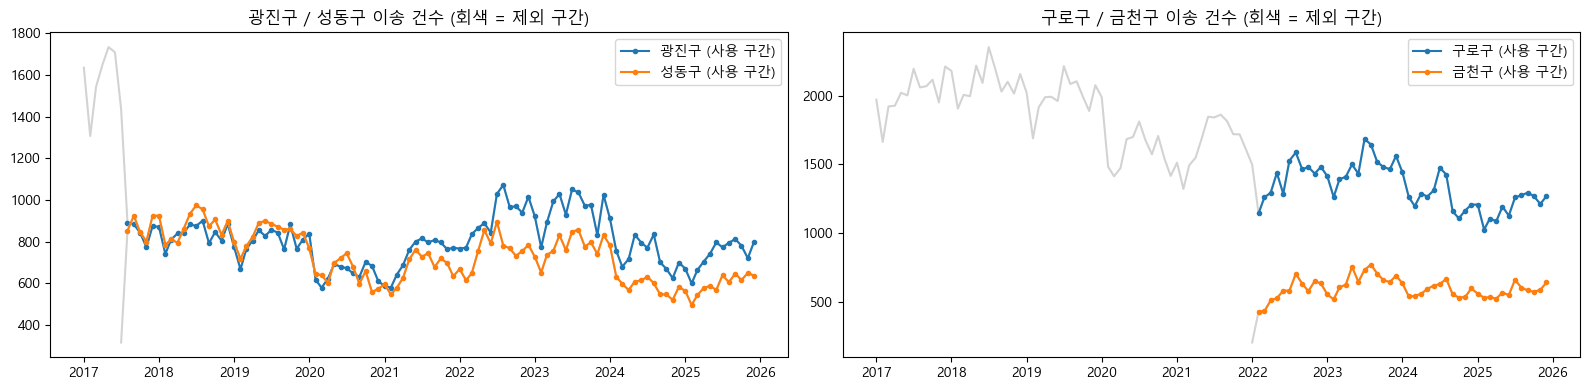

In [8]:
# 구별 월별 이송 건수 추이 (관할 변경 구 확인)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, pair in zip(axes, [('광진구', '성동구'), ('구로구', '금천구')]):
    for gu in pair:
        g_all = api[api['District'] == gu]
        g_use = monthly[monthly['District'] == gu]
        ax.plot(g_all['ds'], g_all['transport_cnt'], color='lightgray')
        ax.plot(g_use['ds'], g_use['transport_cnt'], marker='.', label=f'{gu} (사용 구간)')
    ax.set_title(' / '.join(pair) + ' 이송 건수 (회색 = 제외 구간)')
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'station_split_check.png')
plt.show()

### 3-2. 시계열 분해 (서울 전체 월별 이송 건수)
- `seasonal_decompose` : 실제값을 추세(trend) + 계절성(seasonal) + 잔차(resid)로 분리
- 덧셈 모델(additive) : 계절 변동 폭이 해마다 비슷할 때 사용
- `period=12` : 12개월 주기
- 준비 조건 : 날짜를 인덱스로, 빈 달 없이 연속
- 서울 전체 합계 : 관할이 바뀌어도 합계는 같으므로 3장에서 빼기 전 API 원본 사용
- 확인 목적 : 계절성이 크면 `월`·`전년동월` 특성이 필요하다는 근거

**결과 해석** : 계절 효과 폭(최대−최소)이 월평균의 약 20% 이상 → 계절성 무시 불가 → `월`(원-핫)·`전년동월` 특성 유지

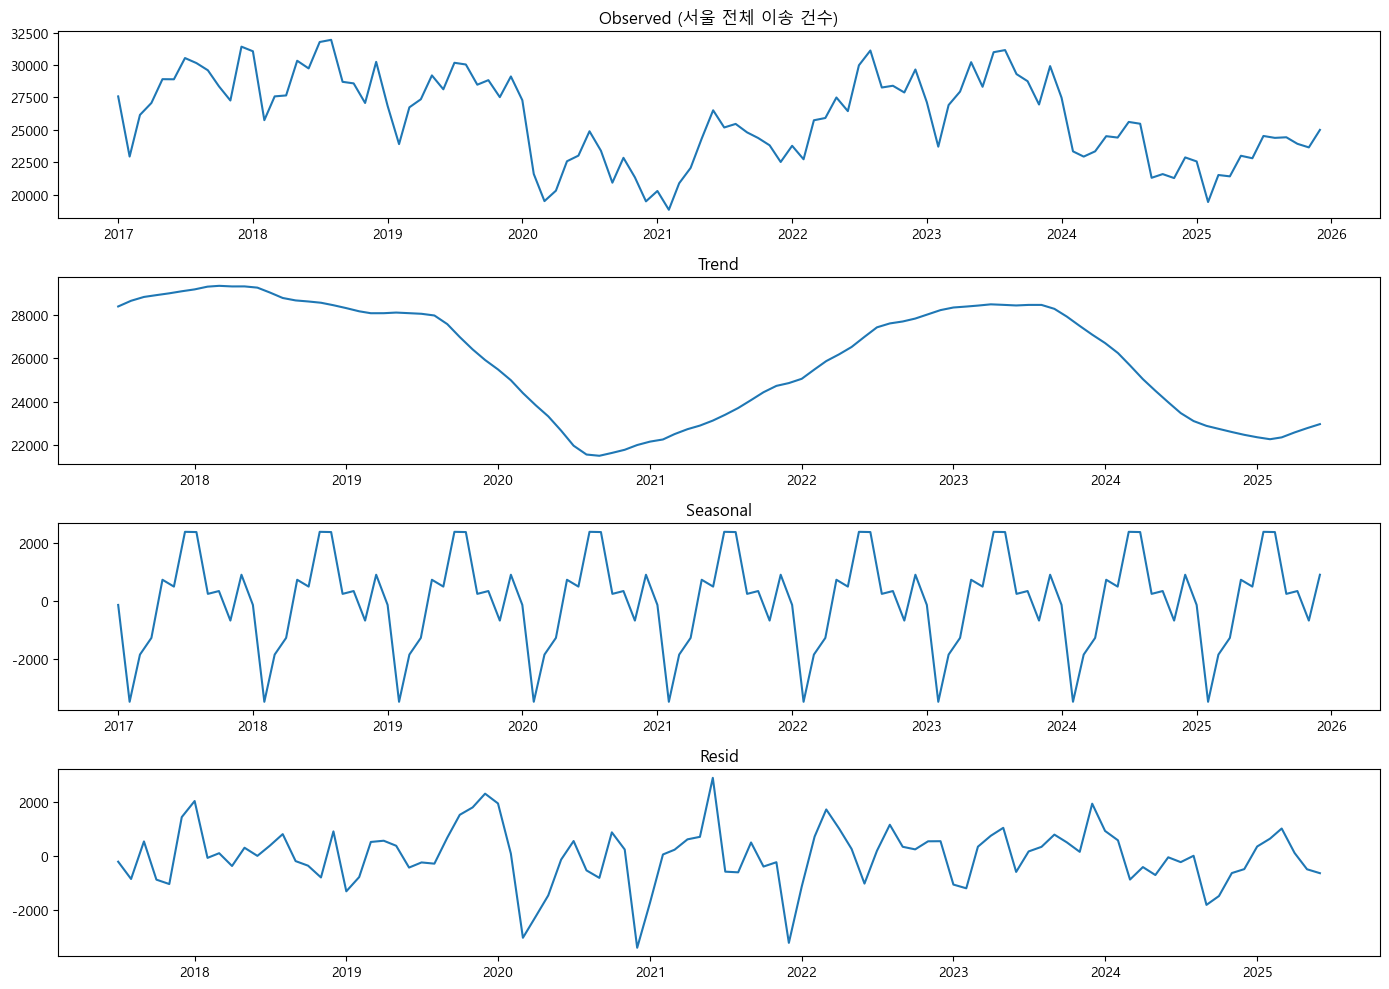

월별 계절 효과 (건, 평균 대비)
ds
1     -141.0
2    -3467.0
3    -1847.0
4    -1273.0
5      722.0
6      488.0
7     2368.0
8     2360.0
9      238.0
10     335.0
11    -679.0
12     895.0
계절 효과 폭 : 5,835건 / 월평균 25,942건


In [9]:
# 서울 전체 합계는 관할 변경과 무관 -> 제외 전 API 원본으로 합계
city = api.groupby('ds')['transport_cnt'].sum()
city = city.asfreq('MS').interpolate()     # 빈 달이 있으면 앞뒤 값으로 선형 보간

rslt = seasonal_decompose(city, period=12, model='additive')

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10))
axes[0].plot(rslt.observed)
axes[0].set_title('Observed (서울 전체 이송 건수)')
axes[1].plot(rslt.trend)
axes[1].set_title('Trend')
axes[2].plot(rslt.seasonal)
axes[2].set_title('Seasonal')
axes[3].plot(rslt.resid)
axes[3].set_title('Resid')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_decompose.png')
plt.show()

season_by_month = rslt.seasonal.groupby(rslt.seasonal.index.month).mean()
print('월별 계절 효과 (건, 평균 대비)')
print(season_by_month.round(0).to_string())
print(f'계절 효과 폭 : {season_by_month.max() - season_by_month.min():,.0f}건 / 월평균 {city.mean():,.0f}건')

## 4. 설명용 데이터 (생활인구 · 사고 원인 · 의료이용)
- 생활인구 : 일별 표 → 6장에서 월평균으로 변환
- 사고 원인 : 연 단위, 원인별 구조 인원
- 의료이용 : 연 단위, 수요(유출률)와 공급(유입률)을 구·연도 기준으로 합침

In [10]:
pop = raw['population_rf'].copy()
accident = raw['accident_cause_onehot'].copy()

demand = raw['medical_flow_district_demand'].copy()
supply = raw['medical_flow_district_supply'].copy()
medical = demand.merge(supply, on=['ds', 'District'], how='outer')
medical['연도'] = medical['ds'].dt.year
medical = medical.drop(columns='ds')

print('생활인구 :', pop.shape, pop['ds'].min().date(), '~', pop['ds'].max().date())
print('사고 원인:', accident.shape, accident['ds'].dt.year.min(), '~', accident['ds'].dt.year.max())
print('의료이용 :', medical.shape, medical['연도'].min(), '~', medical['연도'].max())

생활인구 : (76000, 16) 2018-04-05 ~ 2026-07-31
사고 원인: (500, 16) 2006 ~ 2025
의료이용 : (150, 12) 2019 ~ 2024


### 4-1. 실시간 응급실 병상 데이터 분리
`realtime_er_beds`는 월별 구급 수요 예측의 학습 특성으로 사용하지 않습니다. 대신 웹 서비스에서 **응급의료기관·가용병상 현황**을 제공하기 위한 별도 데이터로 관리합니다.


In [11]:
if 'realtime_er_beds' in raw:
    beds = raw['realtime_er_beds'].copy()
    print('병원 수:', beds['Hospital_ID'].nunique())
    print('자치구 수:', beds['District'].nunique())
    print('실시간 자료가 없는 구:', sorted(VALID_GU - set(beds['District'])))

    bed_summary = (
        beds.groupby('District')
            .agg(
                응급의료기관수=('Hospital_ID', 'nunique'),
                가용병상수=('Available_Beds', 'sum'),
                과밀기관수=('Is_Overcrowded', 'sum'),
                정보노후기관수=('Is_Stale', 'sum')
            )
            .reindex(GU_LIST, fill_value=0)     # 자료 없는 구도 0으로 포함
            .rename_axis('District')
            .reset_index()
    )
    bed_summary['수집시각'] = beds['collected_at'].max()
    bed_summary.to_csv(ML_DATA_DIR / 'ref_er_beds_realtime.csv', index=False, encoding='utf-8-sig')
    display(bed_summary.sort_values('가용병상수', ascending=False))
else:
    beds = None
    print('[주의] realtime_er_beds.csv가 없습니다.')


병원 수: 51
자치구 수: 23
실시간 자료가 없는 구: ['강북구', '마포구']


,District,응급의료기관수,가용병상수,과밀기관수,정보노후기관수,수집시각
19,영등포구,6,53.0,0,0,2026-09-29 16:15:01.757547
10,동대문구,4,35.0,0,0,2026-09-29 16:15:01.757547
18,양천구,3,28.0,0,0,2026-09-29 16:15:01.757547
11,동작구,2,20.0,0,0,2026-09-29 16:15:01.757547
8,노원구,3,19.0,0,0,2026-09-29 16:15:01.757547
16,성북구,1,18.0,0,0,2026-09-29 16:15:01.757547
1,강동구,3,16.0,0,0,2026-09-29 16:15:01.757547
9,도봉구,1,15.0,0,0,2026-09-29 16:15:01.757547
5,광진구,2,12.0,0,0,2026-09-29 16:15:01.757547
21,은평구,2,11.0,0,0,2026-09-29 16:15:01.757547


### 4-2. 안전데이터포털 병상 자료 (참고용)
- 두 파일 모두 **모델 특성에서 제외**, 참고 표로만 저장
- `DSSP-IF-00606` : 구별 병상 수 (2014~2017, 단위 '개')
  - 2017년 값 = 2016년 값 그대로 → 2017은 제외
  - 연 단위·2016년에서 끝남 → 2017~2025 학습 기간과 맞지 않음
- `DSSP-IF-10288` : 전국 병·의원 목록 (한 시점 스냅샷)
  - 자치구 : 주소(`ADDR`) 두 번째 단어
  - `EMRO == 1` : 응급실 운영 기관 (실시간 병상 병원 ID와 대조해 확인)
  - `PRMSN_SCKBD_CNT` : 허가 병상 수
  - 시간에 따라 변하지 않는 값 → 월별 예측 특성으로 부적합
- 파일 위치 : `data` 폴더 → 없으면 `outputs` 폴더에서 찾음

In [12]:
# 법정동 코드 앞 5자리 -> 자치구
GU_CODE = {
    '11110': '종로구', '11140': '중구', '11170': '용산구', '11200': '성동구', '11215': '광진구',
    '11230': '동대문구', '11260': '중랑구', '11290': '성북구', '11305': '강북구', '11320': '도봉구',
    '11350': '노원구', '11380': '은평구', '11410': '서대문구', '11440': '마포구', '11470': '양천구',
    '11500': '강서구', '11530': '구로구', '11545': '금천구', '11560': '영등포구', '11590': '동작구',
    '11620': '관악구', '11650': '서초구', '11680': '강남구', '11710': '송파구', '11740': '강동구',
}


def find_in_folders(name):
    # data 폴더 먼저, 없으면 outputs 폴더
    for folder in [DATA_DIR, OUT_DIR]:
        path = find_file(folder, name)
        if path is not None:
            return path
    return None


# (1) 구별 병상 수 (DSSP-IF-00606)
path = find_in_folders('safety_DSSP-IF-00606')
if path is not None:
    bed_stat = pd.read_csv(path, encoding='utf-8-sig', dtype={'DONG_CD': str})
    bed_stat['District'] = bed_stat['DONG_CD'].str[:5].map(GU_CODE)
    bed_stat = bed_stat[bed_stat['District'].notna()]

    # 2017 = 2016 복사본인지 확인 후 제외
    p = bed_stat.pivot_table(index='District', columns='YR', values='STATS_VL')
    if 2017 in p.columns and p[2017].equals(p[2016]):
        print('2017년 값이 2016년과 모두 같음 -> 2017 제외')
        p = p.drop(columns=2017)
    p.columns = [f'병상수_{c}' for c in p.columns]
    p = p.reindex(GU_LIST).reset_index()
    p.to_csv(ML_DATA_DIR / 'ref_beds_2014_2016.csv', index=False, encoding='utf-8-sig')
    display(p)
else:
    print('[없음] safety_DSSP-IF-00606.csv')


2017년 값이 2016년과 모두 같음 -> 2017 제외


,District,병상수_2014,병상수_2015,병상수_2016
0,강남구,7157,7335,7564
1,강동구,5699,5843,5855
2,강북구,2247,2121,1989
3,강서구,3695,3377,3547
4,관악구,2166,2430,2446
5,광진구,2643,2470,2360
6,구로구,3307,3784,3721
7,금천구,1829,1935,2031
8,노원구,3447,3551,3924
9,도봉구,2947,2832,3022


In [13]:
# (2) 구별 응급실 운영기관 (DSSP-IF-10288) - 큰 파일이라 필요한 컬럼만 읽기
path = find_in_folders('safety_DSSP-IF-10288')
if path is not None:
    use_cols = ['HSPTL_ID', 'INST_NM', 'ADDR', 'EMRO', 'PRMSN_SCKBD_CNT']
    hosp = pd.read_csv(path, encoding='utf-8-sig', usecols=use_cols, low_memory=False)
    hosp = hosp[hosp['ADDR'].str.startswith('서울', na=False)].copy()
    hosp['District'] = hosp['ADDR'].str.split().str[1]
    hosp = hosp[hosp['District'].isin(VALID_GU)]
    hosp['허가병상수'] = pd.to_numeric(hosp['PRMSN_SCKBD_CNT'], errors='coerce').fillna(0)

    er = hosp[hosp['EMRO'] == 1]
    print('서울 의료기관:', len(hosp), '/ 응급실 운영기관:', len(er))

    # 실시간 병상 병원이 응급실 운영기관 목록에 있는지 대조
    if beds is not None:
        matched = beds['Hospital_ID'].isin(er['HSPTL_ID']).sum()
        print(f'실시간 병상 병원 {len(beds)}곳 중 응급실 운영기관과 일치: {matched}곳')

    er_summary = (
        er.groupby('District')
          .agg(응급실운영기관수=('HSPTL_ID', 'nunique'), 응급실기관_허가병상수=('허가병상수', 'sum'))
          .reindex(GU_LIST, fill_value=0)
          .rename_axis('District')
          .reset_index()
    )
    if beds is not None:
        er_summary['실시간자료_기관수'] = er_summary['District'].map(beds.groupby('District')['Hospital_ID'].nunique()).fillna(0).astype(int)
    er_summary.to_csv(ML_DATA_DIR / 'ref_er_institutions.csv', index=False, encoding='utf-8-sig')
    display(er_summary)
else:
    print('[없음] safety_DSSP-IF-10288.csv')


서울 의료기관: 25510 / 응급실 운영기관: 70
실시간 병상 병원 51곳 중 응급실 운영기관과 일치: 50곳


,District,응급실운영기관수,응급실기관_허가병상수,실시간자료_기관수
0,강남구,5,3215.0,2
1,강동구,3,2308.0,3
2,강북구,3,431.0,0
3,강서구,5,1495.0,2
4,관악구,4,642.0,1
5,광진구,2,1078.0,2
6,구로구,2,1202.0,2
7,금천구,1,225.0,1
8,노원구,3,1493.0,3
9,도봉구,1,381.0,1


## 5. 중복·쓸모없는 컬럼 점검
- 같은 값 컬럼 : 두 컬럼씩 `equals()`로 비교 → 뒤쪽 컬럼 제외
- 값이 하나뿐인 컬럼 : `nunique() <= 1` → 예측에 정보 없음
- 제외 기록 : `excluded_columns.csv`로 저장

In [14]:
excluded = []   # [표, 컬럼, 이유]


def drop_useless_columns(df, name, keys):
    cols = [c for c in df.columns if c not in keys]
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            if a in df.columns and b in df.columns and df[a].equals(df[b]):
                df = df.drop(columns=b)
                excluded.append([name, b, f'{a}와 값이 같음'])
    for c in [c for c in df.columns if c not in keys]:
        if df[c].nunique(dropna=False) <= 1:
            df = df.drop(columns=c)
            excluded.append([name, c, '값이 하나뿐임'])
    return df


pop = drop_useless_columns(pop, '생활인구', ['ds', 'District'])
accident = drop_useless_columns(accident, '사고원인', ['ds', 'District'])
if medical is not None:
    medical = drop_useless_columns(medical, '의료이용', ['연도', 'District'])

pop_cols = [c for c in pop.columns if c not in ['ds', 'District']]

excluded_df = pd.DataFrame(excluded, columns=['표', '컬럼', '이유'])
excluded_df.to_csv(ML_DATA_DIR / 'excluded_columns.csv', index=False, encoding='utf-8-sig')
print(excluded_df if len(excluded_df) else '제외된 컬럼 없음')

      표        컬럼             이유
0  생활인구  pop_peak  일최대인구수와 값이 같음


## 6. 이송 건수 학습 데이터 (자치구 × 월)

예측 시점에 이미 알고 있는 **과거 값만** 특성으로 사용합니다.

| 특성 | 의미 |
|---|---|
| `전월_transport_cnt` | 지난달 이송 건수 |
| `전년동월_y`, `전년동월_transport_cnt` | 작년 같은 달 출동·이송 건수 |
| `전월_생활인구` | 지난달 생활인구 월평균 |
| `전년_사고원인` | 작년 원인별 구조 인원 |
| `전년_의료이용` | 작년 유출률·유입률 등 |

- 과거 값 붙이는 원리 : 과거 표의 날짜를 n개월 뒤로 민 다음 날짜·구 기준으로 병합
- 같은 함수로 미래 입력 행(9장)도 계산 : 학습과 예측의 특성 계산 방식 일치
- 지난달 출동 건수(`전월_y`)는 제외 : 미래 달의 출동 건수는 예측하지 않으므로 계산 불가

### 6-0. 생활인구 날짜 연속성 확인
생활인구를 월평균으로 집계하기 전에 자치구별 관측일수와 누락일수를 확인합니다. 또한 월평균이 며칠치 자료로 계산되었는지 `생활인구_관측일수`로 따로 기록합니다. 이 컬럼은 품질 확인용이며 모델 특성에는 넣지 않습니다.


In [15]:
pop_check = (
    pop.groupby('District')
       .agg(
           시작일=('ds', 'min'),
           종료일=('ds', 'max'),
           관측일수=('ds', 'nunique')
       )
)
pop_check['예상일수'] = (pop_check['종료일'] - pop_check['시작일']).dt.days + 1
pop_check['누락일수'] = pop_check['예상일수'] - pop_check['관측일수']
display(pop_check.sort_values('누락일수', ascending=False))


,시작일,종료일,관측일수,예상일수,누락일수
District,,,,,
강남구,2018-04-05,2026-07-31,3040,3040,0
서대문구,2018-04-05,2026-07-31,3040,3040,0
중구,2018-04-05,2026-07-31,3040,3040,0
종로구,2018-04-05,2026-07-31,3040,3040,0
은평구,2018-04-05,2026-07-31,3040,3040,0
용산구,2018-04-05,2026-07-31,3040,3040,0
영등포구,2018-04-05,2026-07-31,3040,3040,0
양천구,2018-04-05,2026-07-31,3040,3040,0
송파구,2018-04-05,2026-07-31,3040,3040,0


In [16]:
# 생활인구 : 일별 -> 월평균
pop_month = pop.copy()
pop_month['ds'] = month_start(pop_month['ds'])

# 월평균이 며칠치 자료로 계산되었는지 품질 확인용으로 보관
pop_days = (
    pop_month.groupby(['ds', 'District'])
             .size()
             .reset_index(name='생활인구_관측일수')
)
pop_month = pop_month.groupby(['ds', 'District'], as_index=False)[pop_cols].mean()
pop_month_quality = pop_month.merge(pop_days, on=['ds', 'District'], how='left')
print('월별 생활인구 관측일수 분포')
display(pop_month_quality['생활인구_관측일수'].describe())


def add_past(df, past_df, cols, months, prefix):
    # past_df 날짜를 months개월 뒤로 옮겨 붙이기 = 'months개월 전 값'
    past = past_df[['ds', 'District'] + cols].copy()
    past['ds'] = past['ds'] + pd.DateOffset(months=months)
    past.columns = ['ds', 'District'] + [prefix + c for c in cols]
    return df.merge(past, on=['ds', 'District'], how='left')


def add_last_year(df, year_df, prefix='전년_'):
    # 연 단위 표를 '작년 값'으로 붙이기
    y = year_df.copy()
    y['연도'] = y['연도'] + 1
    y.columns = [c if c in ['연도', 'District'] else prefix + c for c in y.columns]
    return df.merge(y, on=['연도', 'District'], how='left')


acc_year = accident.assign(연도=accident['ds'].dt.year).drop(columns='ds')


def make_transport_features(base, hist):
    # base : ds, District 뼈대 / hist : 월별 출동·이송 기록
    df = base[['ds', 'District']].copy()
    df['연도'] = df['ds'].dt.year
    df['월'] = df['ds'].dt.month
    df = add_past(df, hist, ['transport_cnt'], 1, '전월_')
    df = add_past(df, hist, ['y', 'transport_cnt'], 12, '전년동월_')
    df = add_past(df, pop_month, pop_cols, 1, '전월_')
    df = add_last_year(df, acc_year)
    if medical is not None:
        df = add_last_year(df, medical)
    return df


hist = monthly[['ds', 'District', 'y', 'transport_cnt']]
target_rows = monthly[monthly['transport_cnt'].notna()]

transport_df = make_transport_features(target_rows, hist)
transport_df = transport_df.merge(target_rows[['ds', 'District', '출처', 'transport_cnt']], on=['ds', 'District'])
transport_df = transport_df.sort_values(['District', 'ds']).reset_index(drop=True)

transport_df.to_csv(ML_DATA_DIR / 'transport_dataset.csv', index=False, encoding='utf-8-sig')
print(transport_df.shape)
print(transport_df.tail())

월별 생활인구 관측일수 분포


count    2500.000000
mean       30.400000
std         0.916698
min        26.000000
25%        30.000000
50%        31.000000
75%        31.000000
max        31.000000
Name: 생활인구_관측일수, dtype: float64

(2564, 46)
             ds District    연도   월  전월_transport_cnt  전년동월_y  \
2559 2025-08-01      중랑구  2025   8             993.0  2157.0   
2560 2025-09-01      중랑구  2025   9             926.0  1763.0   
2561 2025-10-01      중랑구  2025  10             928.0  1751.0   
2562 2025-11-01      중랑구  2025  11             944.0  1649.0   
2563 2025-12-01      중랑구  2025  12             908.0  1787.0   

      전년동월_transport_cnt   전월_total_pop    전월_내국인생활인구수  전월_장기체류외국인인구수  \
2559               967.0  332115.917242  325666.035129    5819.954571   
2560               809.0  330988.594161  324598.049610    5858.001445   
2561               801.0  330940.287970  324628.369530    5808.762683   
2562               760.0  332109.469406  325626.492639    5903.367194   
2563               830.0  331663.582193  325443.876787    5722.575353   

      전월_단기체류외국인인구수      전월_일최대인구수      전월_일최소인구수     전월_day_pop  \
2559     629.927552  364492.726581  294889.851329  303959.787897   
2560     532.543119  361583.9

## 7. 인구 밀집 학습 데이터 (자치구 × 일)
- 정답 : `일최대인구수`
- 특성 : 월·요일·주말 여부, 전일 생활인구, 7일 전 같은 요일의 일최대인구수
- 전일 값 원리 : 구별·날짜순 정렬 → 구별로 묶은 뒤 `shift(1)`로 하루씩 밀기
- 빈 날짜 대비 : 날짜 차이가 1일(7일)이 아닌 행은 빈 값 처리
- `요일`·`월`·`주말여부` : 상관계수 선택 대상에서 빼고 `population_selected.csv`에 항상 저장

In [17]:
TARGET_POP = '일최대인구수'

pop_df = pop.sort_values(['District', 'ds']).reset_index(drop=True)   # shift 전에 반드시 정렬
pop_df['월'] = pop_df['ds'].dt.month
pop_df['요일'] = pop_df['ds'].dt.dayofweek          # 0=월요일 ... 6=일요일
pop_df['주말여부'] = (pop_df['요일'] >= 5).astype(int)

g = pop_df.groupby('District')
gap1 = pop_df['ds'] - g['ds'].shift(1)      # 바로 앞 행과의 날짜 차이
gap7 = pop_df['ds'] - g['ds'].shift(7)

lag1 = g[pop_cols].shift(1)
lag1[gap1 != pd.Timedelta(days=1)] = np.nan     # 하루 전이 아니면 빈 값
lag1.columns = ['전일_' + c for c in pop_cols]
pop_df['7일전_' + TARGET_POP] = g[TARGET_POP].shift(7).where(gap7 == pd.Timedelta(days=7))

population_df = pd.concat(
    [pop_df[['ds', 'District', '월', '요일', '주말여부', '7일전_' + TARGET_POP]], lag1, pop_df[[TARGET_POP]]],
    axis=1).dropna().reset_index(drop=True)

population_df.to_csv(ML_DATA_DIR / 'population_dataset.csv', index=False, encoding='utf-8-sig')
print(population_df.shape)


(75825, 20)


## 8. 특성 선택 (상관계수 기준)
- 계산 기간 : `SELECT_END` 이전 행만 사용 → 테스트 기간 정답이 특성 선택에 섞이지 않음
- 결측률 20% 초과 컬럼 제외 : 행 손실 방지
- 정답과 상관 |r| < 0.3 제외 : 직선 관계가 약한 컬럼
- 이미 고른 컬럼과 |r| ≥ 0.9 제외 : 같은 정보 반복(다중공선성) 방지
- 추가 시 완전행 보존율 70% 미만 제외 : 빈 값 겹침으로 행이 과도하게 줄어드는 것 방지
- 빈 값은 평균·0으로 채우지 않음 : 시계열 왜곡 방지
- `월`은 상관계수 대신 원-핫 인코딩으로 모델에 항상 포함 (계절 효과는 직선 관계가 아님)

In [18]:
def select_features(df, target, candidates, min_corr=0.3, max_inter_corr=0.9,
                    max_missing=0.20, min_row_retention=0.70):
    rows = []
    usable = []
    for col in candidates:
        missing = df[col].isna().mean()
        if missing > max_missing:
            rows.append([col, np.nan, '제외', f'결측 {missing:.0%} > {max_missing:.0%}'])
        else:
            usable.append(col)

    corr_target = df[usable + [target]].corr()[target].drop(target)
    selected = []
    for col in corr_target.abs().sort_values(ascending=False).index:
        r = corr_target[col]
        if pd.isna(r):
            rows.append([col, r, '제외', '상관계수 계산 불가'])
            continue
        if abs(r) < min_corr:
            rows.append([col, r, '제외', f'정답과 상관 약함 (|r| < {min_corr})'])
            continue
        similar = [s for s in selected if abs(df[col].corr(df[s])) >= max_inter_corr]
        if similar:
            rows.append([col, r, '제외', f'{similar[0]}와 너무 비슷함'])
            continue
        retention = df[selected + [col, target]].notna().all(axis=1).mean()
        if retention < min_row_retention:
            rows.append([col, r, '제외', f'추가 시 완전행 보존율 {retention:.0%} < {min_row_retention:.0%}'])
            continue
        selected.append(col)
        rows.append([col, r, '선택', f'완전행 보존율 {retention:.0%}'])

    return selected, pd.DataFrame(rows, columns=['컬럼', '정답과_상관계수', '결과', '이유'])


def draw_heatmap(df, cols, title, save_path):
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(2 + len(cols) * 0.8, 1 + len(cols) * 0.7))
    sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='Blues', mask=mask)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

===== transport (정답: transport_cnt, 선택 계산 2264행 / 전체 2564행) =====
                컬럼  정답과_상관계수 결과                         이유
         전년_총입원연인원       NaN 제외               결측 36% > 20%
       전년_서울내입원연인원       NaN 제외               결측 36% > 20%
       전년_서울외유출연인원       NaN 제외               결측 36% > 20%
            전년_유출률       NaN 제외               결측 36% > 20%
       전년_응급실입원연인원       NaN 제외               결측 60% > 20%
         전년_총처리연인원       NaN 제외               결측 36% > 20%
       전년_서울내환자연인원       NaN 제외               결측 36% > 20%
       전년_서울외유입연인원       NaN 제외               결측 36% > 20%
            전년_유입률       NaN 제외               결측 36% > 20%
       전년_응급실처리연인원       NaN 제외               결측 60% > 20%
  전월_transport_cnt  0.934125 선택                완전행 보존율 99%
전년동월_transport_cnt  0.797099 선택                완전행 보존율 87%
            전년동월_y  0.781286 제외 전년동월_transport_cnt와 너무 비슷함
      전월_night_pop  0.692455 선택                완전행 보존율 83%
       전월_내국인생활인구수  0.658599 제외       전월_night_po

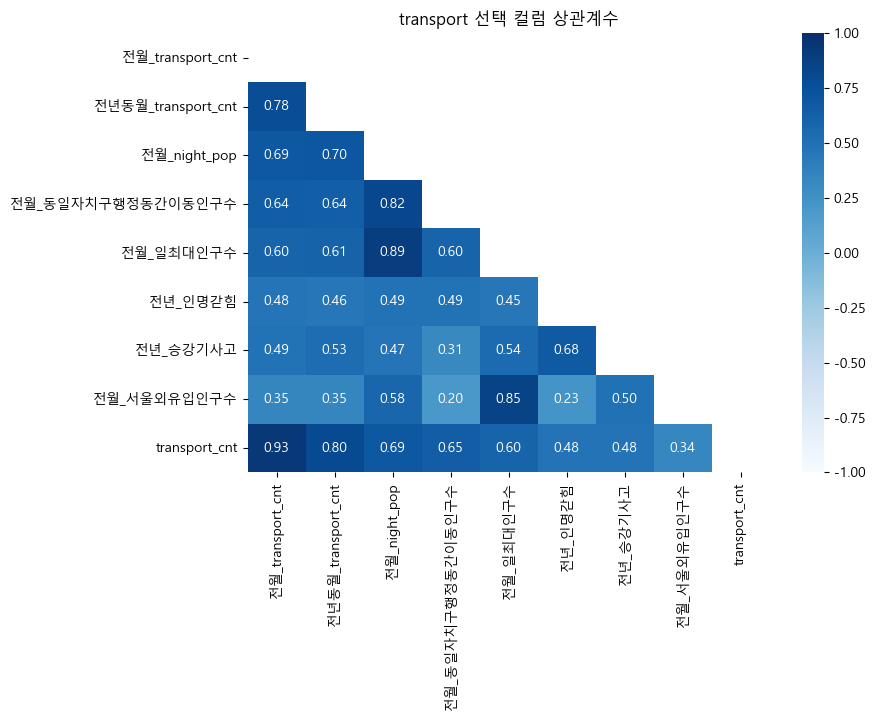

===== population (정답: 일최대인구수, 선택 계산 61400행 / 전체 75825행) =====
               컬럼  정답과_상관계수 결과                    이유
       7일전_일최대인구수  0.979625 선택          완전행 보존율 100%
        전일_일최대인구수  0.959192 제외    7일전_일최대인구수와 너무 비슷함
       전일_day_pop  0.949321 제외    7일전_일최대인구수와 너무 비슷함
     전일_total_pop  0.942672 제외    7일전_일최대인구수와 너무 비슷함
      전일_내국인생활인구수  0.929927 제외    7일전_일최대인구수와 너무 비슷함
     전일_night_pop  0.871928 선택          완전행 보존율 100%
        전일_일최소인구수  0.856459 제외  전일_night_pop와 너무 비슷함
      전일_일최대이동인구수  0.838999 선택          완전행 보존율 100%
      전일_서울외유입인구수  0.781991 제외   전일_일최대이동인구수와 너무 비슷함
     전일_자치구간이동인구수  0.640685 제외   전일_일최대이동인구수와 너무 비슷함
전일_동일자치구행정동간이동인구수  0.599582 선택          완전행 보존율 100%
      전일_pop_diff  0.487847 선택          완전행 보존율 100%
    전일_단기체류외국인인구수  0.274691 제외 정답과 상관 약함 (|r| < 0.3)
    전일_장기체류외국인인구수  0.169925 제외 정답과 상관 약함 (|r| < 0.3)
선택 변수: ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']
-> population_selected.csv : 75825행 중 75825행 저장



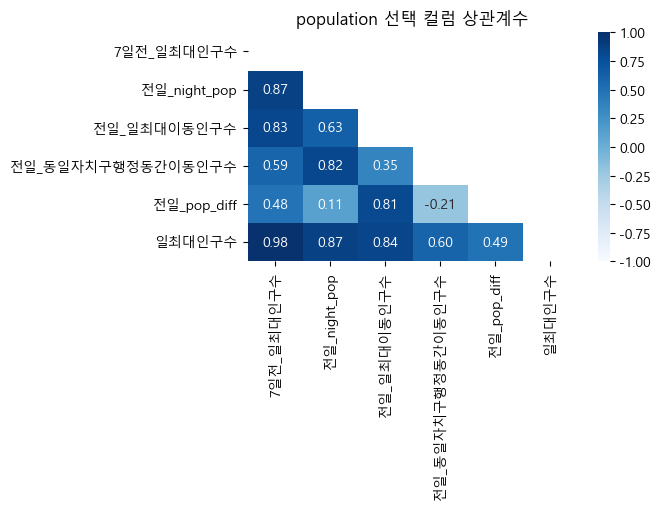

In [19]:
topics = {
    'transport':  (transport_df,  'transport_cnt', ['ds', 'District', '출처', '월']),
    'population': (population_df, TARGET_POP,      ['ds', 'District', '월', '요일', '주말여부']),
}

selected_features = {}
for topic, (df, target, keys) in topics.items():
    candidates = [c for c in df.select_dtypes('number').columns if c != target and c not in keys]
    train_part = df[df['ds'] < SELECT_END]          # 특성 선택은 학습 기간만
    selected, result = select_features(train_part, target, candidates)
    selected_features[topic] = selected

    print(f'===== {topic} (정답: {target}, 선택 계산 {len(train_part)}행 / 전체 {len(df)}행) =====')
    print(result.to_string(index=False))
    result.to_csv(ML_DATA_DIR / f'features_{topic}.csv', index=False, encoding='utf-8-sig')

    selected_df = df[keys + selected + [target]].dropna(subset=selected + [target]).reset_index(drop=True)
    selected_df.to_csv(ML_DATA_DIR / f'{topic}_selected.csv', index=False, encoding='utf-8-sig')
    print(f'선택 변수: {selected}')
    print(f'-> {topic}_selected.csv : {len(df)}행 중 {len(selected_df)}행 저장\n')

    if selected:
        draw_heatmap(train_part, selected + [target], f'{topic} 선택 컬럼 상관계수', RESULT_DIR / f'fig_corr_{topic}.png')


## 9. 미래 예측용 입력 행 (`transport_future.csv`)
- 뼈대 : 마지막 실제 달 다음부터 `FORECAST_MONTHS`개월 × 25개 구
- 특성 계산 : 6장과 같은 `make_transport_features` 사용 (학습 데이터와 계산 방식 일치)
- `전월_transport_cnt` : 첫 달만 실제 값, 이후 달은 빈 값 → 예측 노트북에서 전달 예측값으로 채움 (재귀 예측)
- 그 외 아직 없는 값(작년 의료이용 등) : 구별 가장 최근 값으로 채움 (최근 수준 유지 가정)

In [20]:
last_month = monthly['ds'].max()
future_months = pd.date_range(last_month + pd.DateOffset(months=1), periods=FORECAST_MONTHS, freq='MS')
base = pd.DataFrame([(m, gu) for m in future_months for gu in GU_LIST], columns=['ds', 'District'])

future = make_transport_features(base, hist)

fill_cols = [c for c in future.columns
             if c not in ['ds', 'District', '연도', '월', '전월_transport_cnt']]

# 구별로 학습 데이터에서 확인된 가장 최근 값을 준비
last_known = (
    transport_df.sort_values('ds')
                .groupby('District')[fill_cols]
                .last()
)

# 미래 시점에 아직 알 수 없는 설명변수만 구별 최근값으로 보완
# DataFrame.fillna(last_known)는 인덱스가 달라 제대로 정렬되지 않을 수 있으므로
# District.map()으로 명시적으로 채운다.
for c in fill_cols:
    future[c] = future[c].fillna(future['District'].map(last_known[c]))

feature_cols = [c for c in transport_df.columns if c not in ['출처', 'transport_cnt']]
future = future.reindex(columns=feature_cols)
future = future.sort_values(['ds', 'District']).reset_index(drop=True)

future.to_csv(ML_DATA_DIR / 'transport_future.csv', index=False, encoding='utf-8-sig')
print(f'예측 대상 : {future_months[0]:%Y-%m} ~ {future_months[-1]:%Y-%m}, {len(future)}행')
print('전월_transport_cnt 가 채워진 행 (첫 달만):', future['전월_transport_cnt'].notna().sum())

예측 대상 : 2026-01 ~ 2026-06, 150행
전월_transport_cnt 가 채워진 행 (첫 달만): 25


## 10. 최종 데이터 품질 검증
저장된 학습 데이터의 키 중복, 결측값, 무한대 값, 정답 분포를 마지막으로 확인합니다.


In [21]:
def check_dataset(df, name, keys, target=None):
    print('=' * 60)
    print(name)
    print('=' * 60)
    print('행:', len(df), '/ 열:', len(df.columns))
    print('키 중복:', df.duplicated(keys).sum())

    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    print('\n[결측값]')
    print(missing if len(missing) else '없음')

    numeric = df.select_dtypes(include='number')
    inf_count = np.isinf(numeric.to_numpy()).sum() if len(numeric.columns) else 0
    print('\n무한대 값:', inf_count)

    if target is not None and target in df.columns:
        print('\n[정답 통계]')
        display(df[target].describe())
    print()

check_dataset(
    transport_df,
    '이송 건수 학습 데이터',
    ['ds', 'District'],
    'transport_cnt'
)
check_dataset(
    population_df,
    '생활인구 학습 데이터',
    ['ds', 'District'],
    TARGET_POP
)


이송 건수 학습 데이터
행: 2564 / 열: 46
키 중복: 0

[결측값]
전년_응급실처리연인원           1366
전년_응급실입원연인원           1366
전년_서울외유출연인원            814
전년_총입원연인원              814
전년_유출률                 814
전년_총처리연인원              814
전년_서울내환자연인원            814
전년_서울외유입연인원            814
전년_유입률                 814
전년_서울내입원연인원            814
전월_pop_diff            354
전월_자치구간이동인구수           354
전월_동일자치구행정동간이동인구수      354
전월_서울외유입인구수            354
전월_일최대이동인구수            354
전월_night_pop           354
전월_일최소인구수              354
전월_일최대인구수              354
전월_단기체류외국인인구수          354
전월_장기체류외국인인구수          354
전월_내국인생활인구수            354
전월_total_pop           354
전월_day_pop             354
전년동월_transport_cnt     300
전년동월_y                 300
전월_transport_cnt        25
dtype: int64

무한대 값: 0

[정답 통계]


count    2564.000000
mean     1043.674727
std       265.891631
min       431.000000
25%       844.750000
50%      1042.000000
75%      1237.000000
max      1822.000000
Name: transport_cnt, dtype: float64


생활인구 학습 데이터
행: 75825 / 열: 20
키 중복: 0

[결측값]
없음

무한대 값: 0

[정답 통계]


count    7.582500e+04
mean     4.823813e+05
std      1.702274e+05
min      1.799289e+05
25%      3.839376e+05
50%      4.427859e+05
75%      5.459127e+05
max      1.269318e+06
Name: 일최대인구수, dtype: float64

## 11. 결과 요약


In [22]:
for f in ['transport_dataset.csv', 'transport_selected.csv', 'transport_future.csv', 'features_transport.csv',
          'population_dataset.csv', 'population_selected.csv', 'features_population.csv', 'excluded_columns.csv',
          'ref_er_beds_realtime.csv', 'ref_er_institutions.csv', 'ref_beds_2014_2016.csv']:
    if not (ML_DATA_DIR / f).exists():
        print(f'{f:28s} (없음)')
        continue
    df = pd.read_csv(ML_DATA_DIR / f, encoding='utf-8-sig')
    print(f'{f:28s} {df.shape}')

for topic, cols in selected_features.items():
    print(f'\n{topic} 선택 특성 {len(cols)}개 : {cols}')

transport_dataset.csv        (2564, 46)
transport_selected.csv       (2180, 13)
transport_future.csv         (150, 44)
features_transport.csv       (41, 4)
population_dataset.csv       (75825, 20)
population_selected.csv      (75825, 11)
features_population.csv      (14, 4)
excluded_columns.csv         (1, 3)
ref_er_beds_realtime.csv     (25, 6)
ref_er_institutions.csv      (25, 4)
ref_beds_2014_2016.csv       (25, 4)

transport 선택 특성 8개 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']

population 선택 특성 5개 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']
